<a href="https://colab.research.google.com/github/lukaszradlinski/UM25_26_SL_Lista_2/blob/main/UczenieMaszynowe_25_26_Lista2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analiza Zbiorów Danych
Laboratorium polega na analizie eksploracynej oraz wykonaniu redukcji wymiarowości dwóch zbiorów danych. W trakcie ćwiczenia zbadasz wskazane zbiory danych w następujących zadaniach:

1. Dla obu zbiorów danych:
    * Wczytaj zbiór danych. Opisz poszczególne kolumny - jakie zawierają atrybuty, co opisują. Zdecyduj czy któreś z kolumn należy przekształcić.
    * Zweryfikuj, czy w zbiorze występują wartości brakujące i/lub odstające. Zdecyduj jak (i czy) należy je usunąć.
    * Zbadaj korelacje między zmiennymi. Możesz posłużyć się macierzą korelacji.
    * Zwizualizuj najciekawsze/najważniejsze według Ciebie zależności w zbiorze.
2. Tylko dla zbioru Spotify Tracks:
    * Utwórz nową cechę "emocja" na podstawie dostępnych kolumn.
    * Dokonaj redukcji wymiarowości za pomocą metod *filter* oraz *wrapper*.
    * Zwizualizij zbiór za pomocą PCA oraz t-SNE. Sprawdź, jak na wizualizację wpływa normalizacja oraz standaryzacja danych.


## Zaliczenie laboratorium


 Za zadania można uzyskać maksymalnie 10 punktów według poniższej tabeli:

| ID | Zadanie | Zbiór danych | Ilość punktów |
|----|---------|--------------|---------------|
| 1  |Wczytanie zbioru danych. Określenie typów zmiennych. Opis kolumn. | Titanic, Spotify | 1 pkt |
| 2  |Filtracja danych. Usunięcie brakujących wartości. | Titanic, Spotify | 2 pkt|
| 3  |Analiza korelacji między zmiennymi (korzystając m. in. z macierzy korelacji) | Titanic, Spotify | 2 pkt |
| 4  |Przedstawienie wizualizacji (histogramów, pudełkowych) opisujących dane. | Titanic, Spotify | 2 pkt |
| 5  |Inżynieria i redukcja cech. | Spotify |1 pkt|
| 6 | Wizualizacja zbioru przy redukcji wymiarów poprzez PCA / t-SNE. Analiza wyników. | Spotify | 2 pkt. |

Analizę (punkty 1-4) należy przeprowadzić dla obu zbiorów. Redukcja (5-6) powinna zostać wykonana tylko dla zbioru *Spotify Tracks*.

### Pytania pomocnicze:
- Co decyduje o jakości i trudności zbioru danych? Czy któryś ze zbiorów z ćwiczenia jest łatwiejszy/trudniejszy? Dlaczego?
- Jakie informacje daje nam analiza pojedynczych cech w przeciwieństwie do analizy wielowymiarowej?
- Jakie własności zbioru mogą stanowić problem dla analizy?
- Na czym polega detekcja wartości odstających? Jaki wpływ na wyniki ma wybrana metoda?
- Jakie są wady/zalety metod radzenia sobie z brakującymi wartościami?
- Jak działa PCA i kiedy warto go stosować?
- Jak działa t-SNE i kiedy warto go stosować? Jaka jest fundamentalna różnica względem PCA?
- Na czym polega standaryzacja danych oraz normalizacja danych? Jakie są różnice
pomiędzy tymi metodami?

In [557]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Analiza zbioru danych [*Titanic*](https://www.kaggle.com/competitions/titanic/overview)

10 kwietnia 1912 roku brytyjski transatlantyk Titanic wypływa z Southampton, a 5 dni później schodzi na dno Atlantyku. Z 2208 osób na pokładzie, ocalało jedynie 704 [[1](https://pl.wikipedia.org/wiki/RMS_Titanic#Liczba_ofiar)]. Szanse przeżycia były silnie uzależnione od płci czy klasy podróży.

Zbiór danych Titanic zawiera informacje o 891 pasażerach statku. Podaje on między innymi płeć, klasę podróży, czy numer biletu. Celem tej części listy jest przeanalizowanie zbioru, opisanie wartości w nim występujących, i odpowiedź na pytanie: kto miał największe szanse na przeżycie Titanica?

## Opis danych

In [558]:
# wczytanie zbioru danych
titanic = pd.read_csv("train.csv")

titanic.shape

(891, 12)

In [559]:
# MIEJSCE NA TWÓJ KOD
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## Przekształcenie danych

In [560]:
# MIEJSCE NA TWÓJ KOD
titanic['Sex'] = titanic['Sex'].map({'male': 0, 'female': 1})
titanic['Embarked'] = titanic['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})


## Brakujące wartości

Wskazówki:
- Wartości ciągłe możemy zinterpolować korzystając z gotowej metody [`pandas.DataFrame.interpolate`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.interpolate.html)
- Wartości dyskretne można uzupełnić konkretną wartością używając metody [`pandas.DataFrame.fillna`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html)
- Aby lepiej ocenić czym uzupełnić NaNy, warto wyświetlić kolumnę na wykresie.
- W przypadku dyskretnych wartości, warto również znaleźć wartości unikatowe funkcją `unique()`.

### Wiek pasażera

In [561]:
# MIEJSCE NA TWÓJ KOD
titanic['Age'] = titanic['Age'].interpolate(method = 'linear')

In [562]:
assert titanic['Age'].isnull().values.any() == False, "Kolumna 'wiek' zawiera brakujące wartości"


### Zaokrętowanie

In [563]:
# MIEJSCE NA TWÓJ KOD
titanic['Embarked'] = titanic['Embarked'].fillna('Brak')

In [564]:
assert titanic['Embarked'].isnull().values.any() == False, "Kolumna 'zaokrętowanie' zawiera brakujące wartości"

### Kabina

In [565]:
# MIEJSCE NA TWÓJ KOD
titanic['Cabin'] = titanic['Cabin'].fillna('Brak')

In [566]:
assert titanic['Cabin'].isnull().values.any() == False, "Kolumna 'kabina' zawiera brakujące wartości"

In [567]:
assert titanic.isnull().values.any() == False, "Zbiór danych zawiera brakujące wartości"

## Przedstawienie danych na wykresach

Wybierz 3-4 wykresy które przekazują według Ciebie najwięcej informacji.

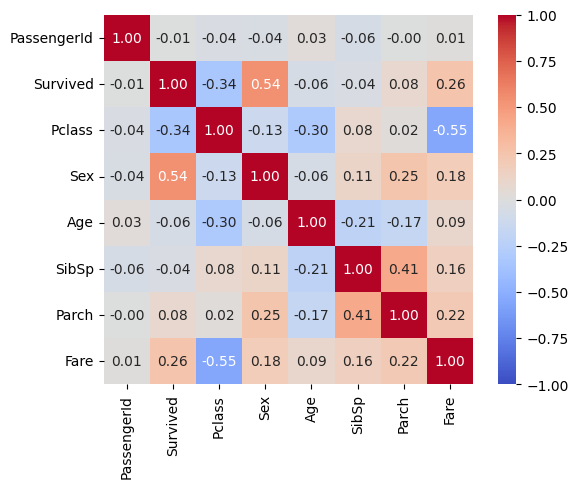

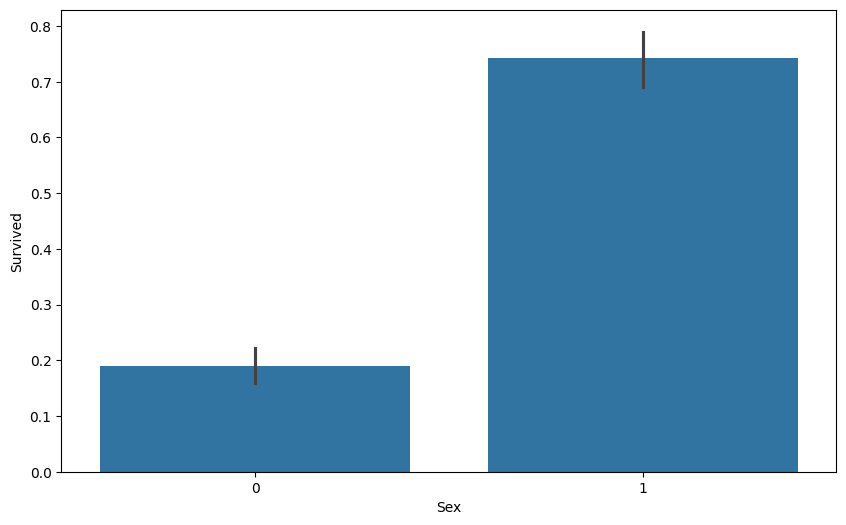

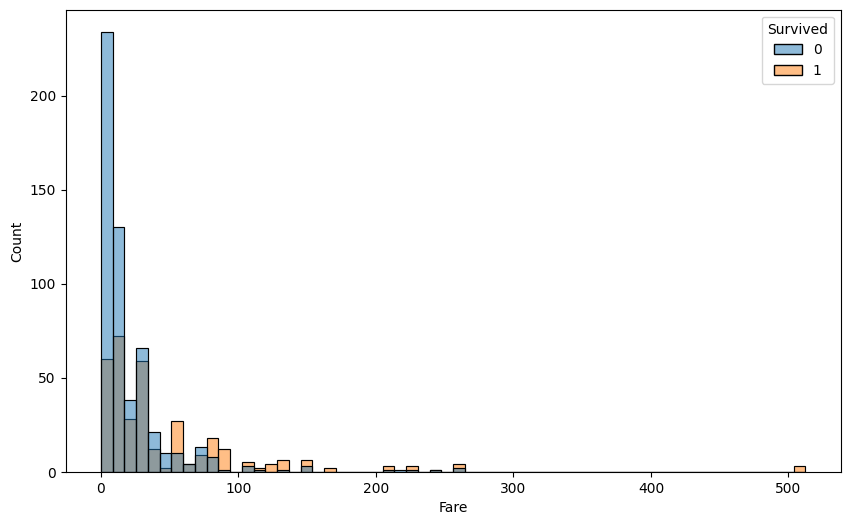

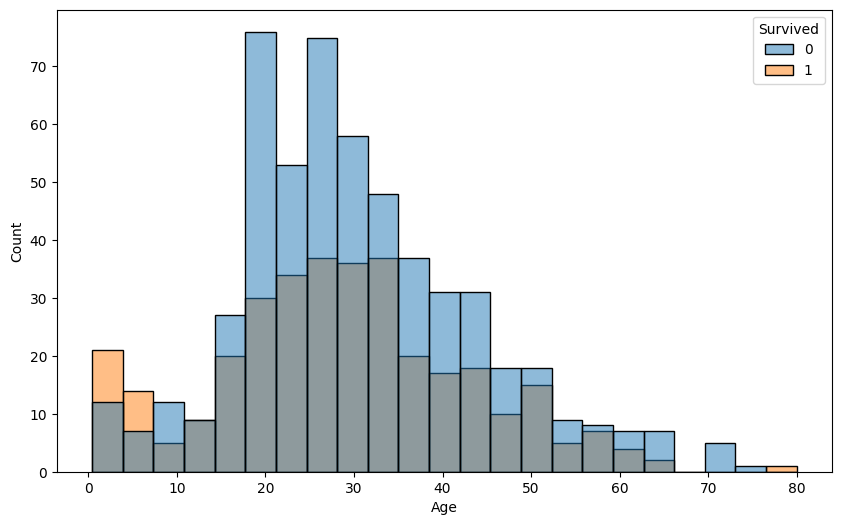

In [568]:
# MIEJSCE NA TWÓJ KOD
sns.heatmap(titanic.corr(numeric_only = True), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, square=True)
plt.show()

plt.figure(figsize = (10,6))
sns.barplot(data = titanic, x = 'Sex', y = 'Survived')
plt.show()


plt.figure(figsize = (10,6))
sns.histplot(data = titanic, x = 'Fare', hue = 'Survived')
plt.show()

plt.figure(figsize = (10,6))
sns.histplot(data = titanic, x = 'Age', hue = 'Survived')
plt.show()



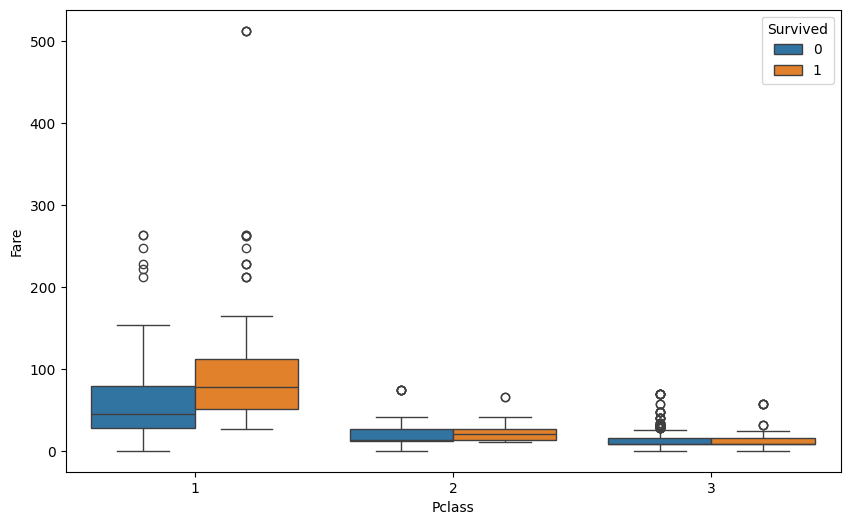

In [569]:
plt.figure(figsize = (10,6))
sns.boxplot(data = titanic, x = 'Pclass', y = 'Fare', hue = 'Survived')
plt.show()

## Podsumowanie - ocena przeżywalności

Na podstawie informacji uzyskanych podczas ćwiczenia - kto miał największe szanse przeżyć Titanica? Jaka cecha (bądź zestaw cech) decydowały o wyniku podróży?

Największe szanse przeżycia miały osoby płci żeńskiej z klasy pierwszej, które zapłaciły więcej niż norma, a ponadto były w wieku 0 - 10 lat.

# Analiza zbioru danych [*Spotify Tracks*](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset)

Celem tej części listy jest analiza dużego, rzeczywistego zbioru danych zawierającego informacje o ponad 100 tysiącach piosenek ze Spotify. Zbiór zawiera kilkanaście cech numerycznych opisujących utwór oraz cechy kategoryczne: wykonawcę, nazwę albumu, gatunek.

Analiza zbioru pozwoli w późniejszym etapie na skuteczną redukcję wymiarowości za pomocą dwóch metod: *filter* oraz *wrapper*. Końcowym celem listy jest przedstawienie wielowymiarowego zbioru na dwuwymiarowym wykresie za pomocą `PCA` oraz `tSNE`.

## Opis danych

In [570]:
spotify = pd.read_csv("dataset.csv")

spotify.shape

(114000, 21)

In [571]:
# MIEJSCE NA TWÓJ KOD
nan_col = spotify.columns[spotify.isnull().any()]
print(nan_col)
spotify = spotify.drop(columns=['Unnamed: 0'])

Index(['artists', 'album_name', 'track_name'], dtype='str')


## Przekształcenia i filtracja danych

In [572]:
# MIEJSCE NA TWÓJ KOD
for col in nan_col:
    spotify[col] = spotify[col].fillna('Brak')
    assert spotify[col].isnull().values.any() == False, f"Kolumna '{col}' zawiera brakujące wartości"




## Wizualizacje

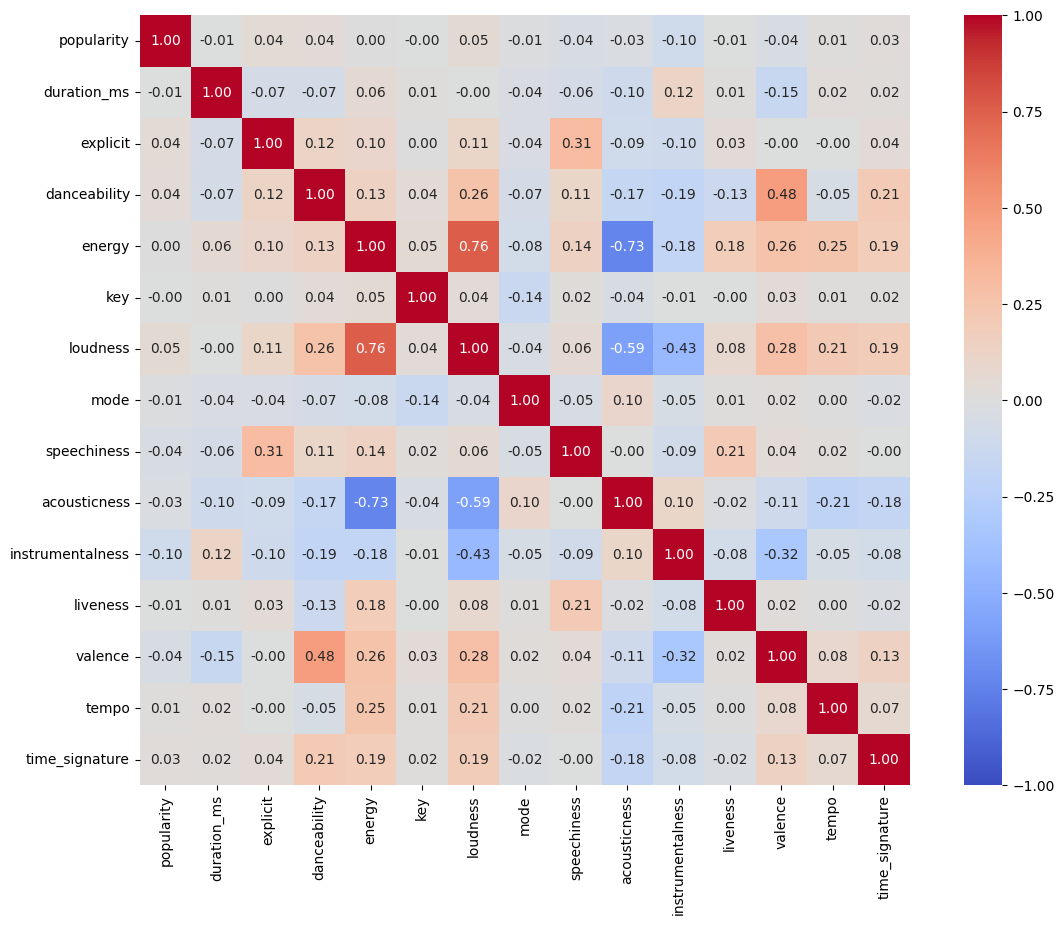

In [573]:
# MIEJSCE NA TWÓJ KOD

plt.figure(figsize = (14,10))
sns.heatmap(
    spotify.corr(numeric_only = True),
    annot = True,
    cmap = 'coolwarm',
    fmt = '.2f',
    vmin = -1,
    vmax = 1,
    square = True
)
plt.show()

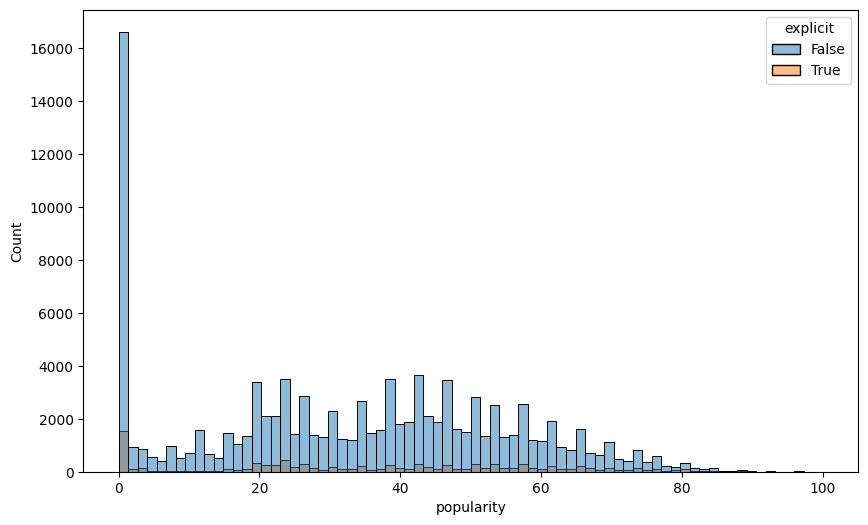

In [574]:
plt.figure(figsize = (10,6))
sns.histplot(data = spotify, x = 'popularity', hue = 'explicit')
plt.show()



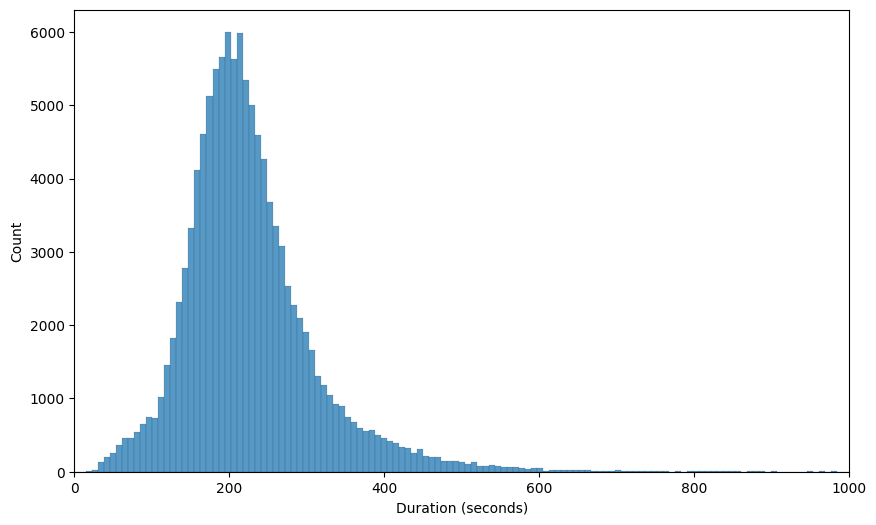

In [575]:
plt.figure(figsize = (10,6))
milliseconds = spotify.copy()
milliseconds['duration_ms'] = milliseconds['duration_ms'] / 1000
sns.histplot(data = milliseconds, x = 'duration_ms')
plt.xlabel('Duration (seconds)')
plt.xlim(0,1000)
plt.show()

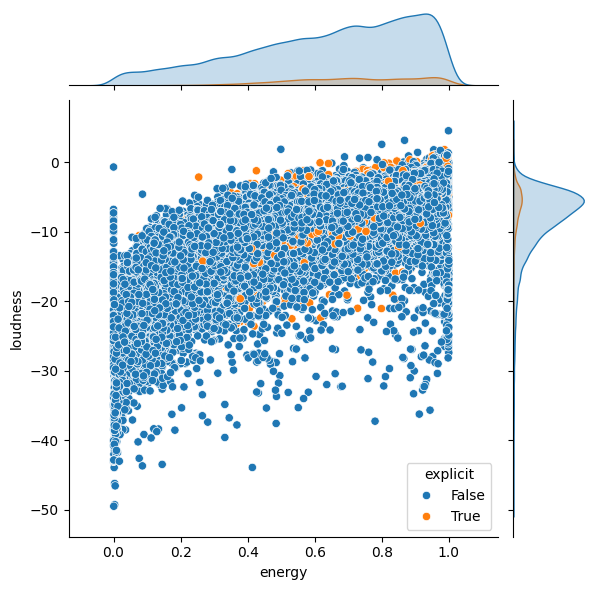

In [576]:
sns.jointplot(data = spotify, x = 'energy', y = 'loudness', hue = 'explicit')
plt.show()

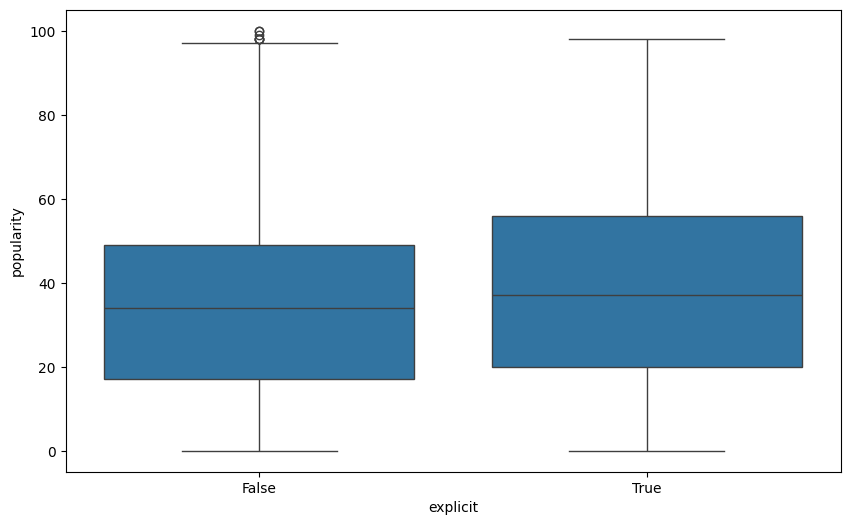

In [577]:
plt.figure(figsize = (10,6))
sns.boxplot(data = spotify, x = 'explicit', y = 'popularity')
plt.show()

## Dodanie nowej cechy - emocja

Emocje w muzyce są przekazywane za pomocą akordów. W zbiorze mamy dostępne informacje nt. klucza i mody piosenki. Ich kombinacja będzie odpowiadać emocji, zgodnie z [tą rozpiską](https://ledgernote.com/blog/interesting/musical-key-characteristics-emotions/).

Moda w zbiorze jest określona jako 0 lub 1, co odpowiada *minor* i odpowiednio *major*.

Klucz jest w [notacji liczbowej](https://en.wikipedia.org/wiki/Pitch_class), czyli 0 odpowiada **C**, 1 odpowiada **C#**, itd.

Twoim zadaniem jest dodanie nowej kolumny "emotion" na podstawie dostępnych informacji.

In [578]:
# dla ułatwienia - gotowe słowniki

key_map = {0: 'C', 1: 'C#', 2: 'D', 3: 'D#', 4: 'E', 5: 'F', 6: 'F#', 7: 'G', 8: 'G#', 9: 'A', 10: 'A#', 11: 'B'}

emotion_map = {
    ('C', 'Major'):  'Happy',
    ('C#', 'Major'): 'Joyful',
    ('D', 'Major'):  'Triumphant',
    ('D#', 'Major'): 'Cruel',
    ('E', 'Major'):  'Noisy',
    ('F', 'Major'):  'Passionate',
    ('F#', 'Major'): 'Bright',
    ('G', 'Major'):  'Rustic',
    ('G#', 'Major'): 'Rich',
    ('A', 'Major'):  'Pastoral',
    ('A#', 'Major'): 'Magnificent',
    ('B', 'Major'):  'Harsh',

    ('C', 'Minor'):  'Sad',
    ('C#', 'Minor'): 'Melancholic',
    ('D', 'Minor'):  'Pensive',
    ('D#', 'Minor'): 'Anxious',
    ('E', 'Minor'):  'Grieving',
    ('F', 'Minor'):  'Tragic',
    ('F#', 'Minor'): 'Gloomy',
    ('G', 'Minor'):  'Serious',
    ('G#', 'Minor'): 'Mournful',
    ('A', 'Minor'):  'Tender',
    ('A#', 'Minor'): 'Dark',
    ('B', 'Minor'):  'Lonely',
}

In [579]:
# MIEJSCE NA TWÓJ KOD
spotify = spotify.assign(letter = spotify['key'].map(key_map))
spotify = spotify.assign(sharp = np.where(spotify['mode'] == 1, 'Major', 'Minor'))
spotify = spotify.assign(emotion = pd.Series(zip(spotify['letter'], spotify['sharp'])).map(emotion_map))
spotify.drop(columns = ['letter', 'sharp'], inplace = True)

## Redukcja wymiarowości

W tej części zadania należy:
- zredukować wymiary zbioru poprzez usunięcie wybranych kolumn korzystając z metod *filter* i *wrapper*
- zwizualizować zbiór danych korzystając z metod redukcji wymiarowości
- zaimplementować standaryzację oraz normalizację
- przeanalizować jak te działania wpływają na wyniki redukcji



### Filter
Analizując pojedyncze kolumny, zdecyduj czy któreś z nich należy usunąć.

In [580]:
# MIEJSCE NA TWÓJ KOD
# Zachowujemy oryginalny spotify do wrappera, filtrujemy do osobnej zmiennej
spotify_filtered = spotify.filter(items=
    ['duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'valence', 'tempo', 'time_signature', 'popularity'])

**Za pomocą wrappera testowałem najwyższe acc i przy tych kolumnach wyszło**

### Wrapper
Korzystając z gotowej implementacji klasyfikatora las losowy, zdecyduj czy któreś z kolumn należy usunąć.

**UWAGA**

To jest bardzo uproszczona implementacja wrappera, która ma na celu jedynie pokazać jego działanie.

In [581]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

def classify(df, features):
    """
    Dostępne cechy:
        'valence', 'year', 'acousticness', 'artists', 'danceability',
        'duration_ms', 'energy', 'explicit', 'id', 'instrumentalness', 'key',
        'liveness', 'loudness', 'mode', 'name', 'popularity', 'release_date',
        'speechiness', 'tempo'
    """
    df = df.drop(columns=["Unnamed: 0", "track_id", "artists", "album_name", "track_name"], errors="ignore")
    df["explicit"] = df["explicit"].astype(int)
    df = df.sample(10000, random_state=42).dropna()

    df["popularity_bracket"] = pd.cut(df["popularity"], bins=[0, 33, 66, 100], labels=["low", "mid", "high"])
    df = df.dropna(subset=["popularity_bracket"])
    y = LabelEncoder().fit_transform(df["popularity_bracket"])
    X = df[features].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42))
    ])
    pipe.fit(X_train, y_train)

    acc  = pipe.score(X_test, y_test)

    print(f"Features  : {features}")
    print(f"Test Acc  : {acc:.4f}")
    return acc

In [582]:
# WYWOŁAJ KLASYFIKATOR W TYM MIEJSCU
example_feats = ['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode',
 'speechiness', 'acousticness', 'instrumentalness', 'valence', 'tempo',
 'time_signature']
base_acc = classify(spotify, example_feats)
best_feats = example_feats.copy()
best_acc = base_acc
print("\n Eliminacja cech:")
for feat in example_feats:
    reduced = [f for f in example_feats if f != feat]
    acc = classify(spotify, reduced)
    if acc > base_acc: 
        base_acc = acc
        example_feats = reduced
print(f"Najlepsze cechy: {example_feats}")
print(f"Najlepsza dokładność: {base_acc}")




Features  : ['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'valence', 'tempo', 'time_signature']
Test Acc  : 0.6237

 Eliminacja cech:
Features  : ['explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'valence', 'tempo', 'time_signature']
Test Acc  : 0.6091
Features  : ['duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'valence', 'tempo', 'time_signature']
Test Acc  : 0.6319
Features  : ['duration_ms', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'valence', 'tempo', 'time_signature']
Test Acc  : 0.6202
Features  : ['duration_ms', 'danceability', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'valence', 'tempo', 'time_signature']
Test Acc  : 0.6202
Features  : ['duration_ms', 'danceability', 'energy',

### Wizualizacje (PCA i t-SNE)

W wizualizacji przetestuj kilka kolumn jako docelowe.

In [583]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn import preprocessing
from scipy import stats

In [584]:
# przykładowe funkcje

def dataframe_xy(df):
    y = df['popularity']
    X = df.select_dtypes(include = [np.number])
    X = X.drop(columns = ['popularity'])
    return X, y

# normalize to [0,1] range
def normalize(X):
    return preprocessing.MinMaxScaler().fit_transform(X)

# standarize (e.g, w/ scikit standard scaler)
def standarize(X):
    return preprocessing.StandardScaler().fit_transform(X)
# remove outliers
def remove_outliers(X, y):
    z_scores = np.abs(stats.zscore(X))
    threshold = 3
    outliers = (z_scores > threshold).any(axis=1)
    return X[~outliers], y[~outliers]


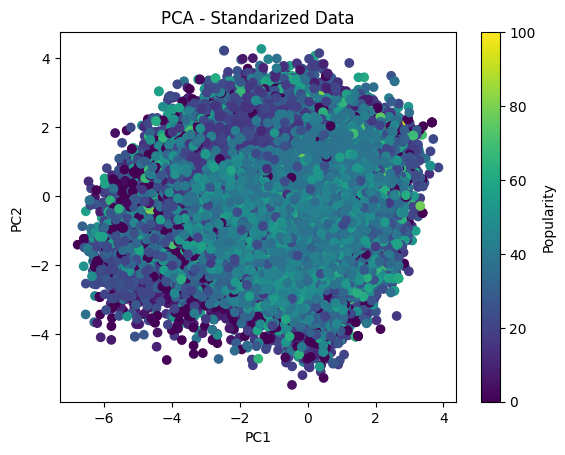

In [585]:
X, y = dataframe_xy(spotify_filtered)
X, y = remove_outliers(X, y)
X_std = standarize(X)
pca = PCA(n_components = 2)
Z_pca_std = pca.fit_transform(X_std)
plt.scatter(Z_pca_std[:, 0], Z_pca_std[:, 1], c = y, cmap = 'viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - Standarized Data")
plt.colorbar(label = "Popularity")
plt.show()


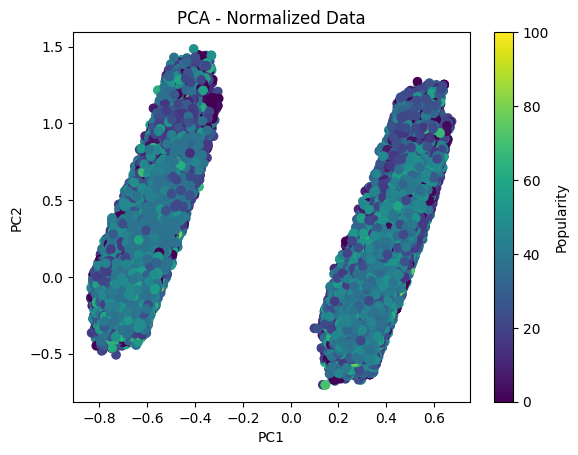

In [586]:
X_norm = normalize(X)
pca = PCA(n_components = 2)
Z_pca_norm = pca.fit_transform(X_norm)
plt.scatter(Z_pca_norm[:, 0], Z_pca_norm[:, 1], c = y, cmap = 'viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - Normalized Data")
plt.colorbar(label = "Popularity")
plt.show()



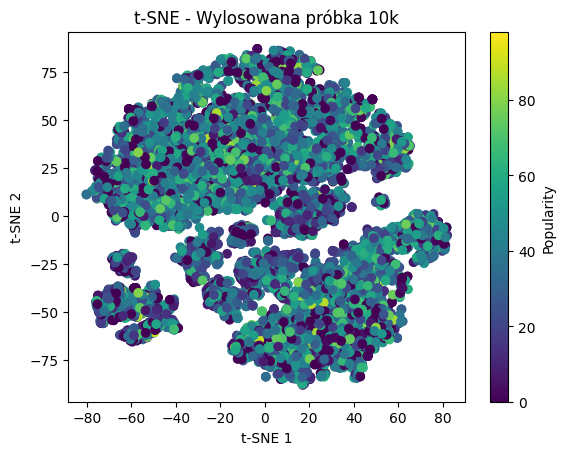

In [587]:
sample_size = 10000
indices = np.random.choice(X_std.shape[0], sample_size, replace=False)
X_std_sample = X_std[indices]
y_sample = y.iloc[indices] 
Z_tsne = TSNE(n_components=2, random_state=42).fit_transform(X_std_sample)
plt.scatter(Z_tsne[:, 0], Z_tsne[:, 1], c=y_sample, cmap='viridis')
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE - Wylosowana próbka 10k")
plt.colorbar(label="Popularity")
plt.show()


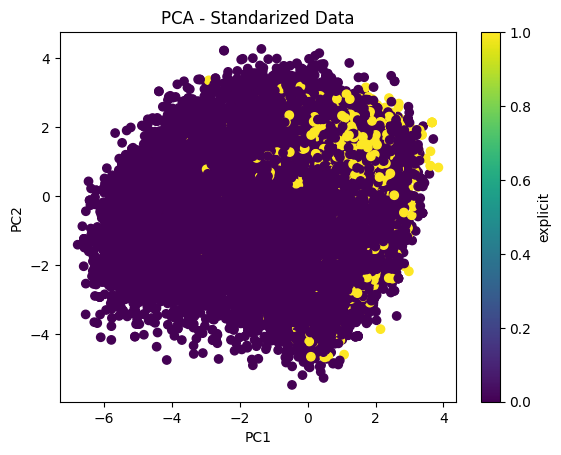

In [588]:
y_explicit = spotify['explicit'].loc[y.index].values
X_std = standarize(X)
pca = PCA(n_components = 2)
Z_pca_std = pca.fit_transform(X_std)
plt.scatter(Z_pca_std[:, 0], Z_pca_std[:, 1], c = y_explicit, cmap = 'viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - Standarized Data")
plt.colorbar(label = "explicit")
plt.show()




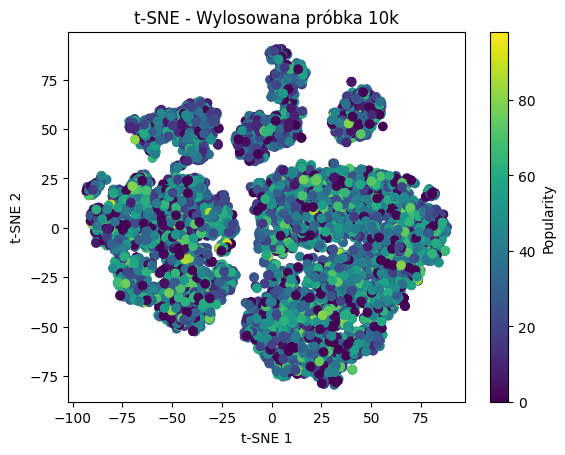

In [589]:
X_norm = normalize(X)
X_norm_sample = X_norm[indices]
Z_tsne_norm = TSNE(n_components=2, random_state=42).fit_transform(X_norm_sample)
plt.scatter(Z_tsne_norm[:, 0], Z_tsne_norm[:, 1], c=y_sample, cmap='viridis')
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE - Wylosowana próbka 10k")
plt.colorbar(label="Popularity")
plt.show()


### Analiza wyników PCA i t-SNE

**PCA — standaryzacja vs normalizacja:**
Na wykresach PCA widać wyraźny podział punktów na dwie chmury wzdłuż pierwszej składowej PC1, gdy dane są po normalizacji. Struktura ta sugeruje, że dominujący kierunek wariancji w danych wynika z silnego, binarnego podziału w cechach (np. `instrumentalness` lub `explicit`). Standaryzacja daje nieco bardziej symetryczny rozkład, ponieważ sprowadza wszystkie cechy do wspólnej skali (średnia 0, odchylenie 1), podczas gdy normalizacja ([0,1]) zachowuje proporcje rozkładów, przez co cechy o skośnych rozkładach mogą dominować.

**Popularność:**
Kolorowanie po `popularity` nie ujawnia wyraźnej separacji — punkty o różnej popularności mieszają się w obu chmurach. Oznacza to, że cechy audio same w sobie nie determinują popularności utworu.

**t-SNE:**
W odróżnieniu od PCA, t-SNE tworzy wiele lokalnych klastrów (wysp), co wynika z nieliniowego charakteru metody — grupuje utwory o podobnych sąsiedztwach w przestrzeni cech. Jednak popularność nadal nie separuje się wyraźnie — potwierdza to obserwację z PCA.
T-SNE na danych znormalizowanych tworzy bardziej zwarte klastry niż na standaryzowanych — normalizacja [0,1] zachowuje proporcje rozkładów, przez co cechy o skośnych rozkładach (np. instrumentalness, speechiness) mogą silniej wpływać na wynik grupowania.

**Kolorowanie po `explicit`:**
Kolorowanie po explicit wyraźnie dzieli zbiór na dwie grupy — utwory oznaczone jako explicit (wartość 1, żółte) skupiają się w odrębnych rejonach przestrzeni cech, co sugeruje że wulgarność treści koreluje z innymi cechami audio, takimi jak energy czy loudness.

